In [1]:
import pandas as pd
import warnings
import nltk
import numpy as np
import torch

from sentence_transformers import SentenceTransformer, util
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,AutoModelForSeq2SeqLM
from langchain_huggingface import HuggingFacePipeline

from IPython.display import display

warnings.filterwarnings('ignore')

c:\Users\parth\OneDrive\Desktop\one\ramayan\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# print(f"PyTorch version: {torch.__version__}")
# print(f"CUDA available: {torch.cuda.is_available()}")
# if torch.cuda.is_available():
#     print(f"CUDA version: {torch.version.cuda}")
#     print(f"GPU Name: {torch.cuda.get_device_name(0)}")

In [3]:
# Define main device for LLM (GPU if available, else CPU)
# device_map="auto" will handle actual placement for the LLM
llm_target_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"LLM will attempt to use: {llm_target_device}")

# Embedding model will be explicitly on CPU
embedding_device = torch.device("cpu")
print(f"Embedding model will use: {embedding_device}")

LLM will attempt to use: cuda:0
Embedding model will use: cpu


In [4]:
try:
    nltk.data.find('tokenizers/punkt')
    print("NLTK 'punkt' tokenizer data found.")
except LookupError:
    print("NLTK 'punkt' tokenizer data not found. Downloading...")
    nltk.download('punkt', quiet=True)
    print("NLTK 'punkt' downloaded.")

NLTK 'punkt' tokenizer data found.


In [5]:
df = pd.read_csv('cleaned_Ramayana_Dataset.csv')
print(f"Dataset loaded with {len(df)} rows.")


Dataset loaded with 18274 rows.


In [6]:

raw_verses = df['English_translation'].tolist()

print(f"Number of raw verses: {len(raw_verses)}")

Number of raw verses: 18274


In [7]:
# Clean verses: Replace None or NaN with empty strings
original_verses_cleaned = []
for verse in raw_verses:
    if verse is None or (isinstance(verse, float) and np.isnan(verse)):
        original_verses_cleaned.append("")
    else:
        original_verses_cleaned.append(str(verse))
print(f"Number of cleaned verses: {len(original_verses_cleaned)}")
if original_verses_cleaned:
    print(f"First cleaned verse example: {original_verses_cleaned[0]}")

# %% [markdown]
# ## Creating Sentence Embeddings (on CPU)

Number of cleaned verses: 18274
First cleaned verse example: ascetic Valmiki inquired Naarada ' engaged deeply austerity study Vedas best eloquent eminent sages ' follows


In [8]:
# You might need to download the 'punkt' resource if you haven't already
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

In [9]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\parth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 1. creating sentence embeddings

In [10]:
model_name_st = 'all-MiniLM-L6-v2'
embedding_model_st = SentenceTransformer(model_name_st, device=embedding_device) # Use pre-defined CPU device

print(f"Encoding {len(original_verses_cleaned)} original verses using {model_name_st} on {embedding_model_st.device}...")

verse_embeddings_np = embedding_model_st.encode(original_verses_cleaned, show_progress_bar=True)
print(f"Created NumPy embeddings of shape: {verse_embeddings_np.shape}")

# Convert NumPy embeddings to PyTorch tensor on CPU
verse_embeddings_tensor = torch.tensor(verse_embeddings_np, device=embedding_device)
print(f"Converted verse_embeddings NumPy array to PyTorch tensor on device: {verse_embeddings_tensor.device}.")


Encoding 18274 original verses using all-MiniLM-L6-v2 on cpu...


Batches: 100%|██████████| 572/572 [00:54<00:00, 10.52it/s]


Created NumPy embeddings of shape: (18274, 384)
Converted verse_embeddings NumPy array to PyTorch tensor on device: cpu.


## 2. Apply the PCA technique to reduce the Dimensionality

In [11]:
np.save('verse_embeddings.npy', verse_embeddings_tensor)

In [12]:
verse_embeddings_tensor = np.load('verse_embeddings.npy')

In [13]:
verse_embeddings_tensor

array([[ 0.04301631, -0.0046518 , -0.07931634, ...,  0.05432126,
        -0.06914657,  0.02081515],
       [ 0.01349139,  0.05336819, -0.00359496, ...,  0.01383984,
         0.00795538, -0.07161106],
       [ 0.00930028,  0.0690031 ,  0.01560736, ...,  0.01424034,
         0.00688834,  0.02257859],
       ...,
       [ 0.04049084,  0.05880749, -0.01722904, ...,  0.03598184,
        -0.00370792, -0.01227243],
       [ 0.05977852,  0.00077831,  0.03994298, ..., -0.03250119,
         0.01992626, -0.11543387],
       [ 0.04246248,  0.02528223, -0.04023981, ...,  0.02308984,
         0.08396813, -0.09718407]], shape=(18274, 384), dtype=float32)

In [14]:
pd.DataFrame(verse_embeddings_tensor)

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,0.043016,-0.004652,-0.079316,0.069743,0.025417,0.020252,0.021243,-0.000596,-0.091399,0.060286,...,-0.019570,0.005199,-0.019236,0.003277,-0.100750,0.003949,0.115275,0.054321,-0.069147,0.020815
1,0.013491,0.053368,-0.003595,-0.046205,-0.112716,0.007230,0.082902,-0.068991,-0.051038,0.035316,...,0.011042,0.001011,0.025720,0.099639,0.007339,-0.019620,0.044338,0.013840,0.007955,-0.071611
2,0.009300,0.069003,0.015607,0.043593,-0.073903,-0.009083,0.107315,-0.027578,-0.082535,0.052754,...,-0.059186,-0.085378,0.056025,0.059300,0.024679,0.063966,0.105279,0.014240,0.006888,0.022579
3,0.049320,0.039634,0.018627,0.033015,-0.005308,0.029437,0.101240,-0.031600,0.080326,0.070455,...,-0.037327,-0.064915,0.024924,0.083022,-0.000358,0.048820,0.105166,-0.019298,-0.013300,0.021098
4,-0.061852,0.022937,-0.059032,-0.034383,-0.097753,-0.052671,0.103135,0.009263,-0.046779,-0.035850,...,0.024607,0.005224,-0.005815,-0.007540,-0.047851,-0.047018,0.103369,0.014846,-0.076449,-0.024820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18269,-0.009003,0.136857,-0.018368,0.033888,0.014566,0.027865,0.009189,-0.031965,-0.001073,-0.030413,...,-0.032462,-0.037680,-0.069645,0.006051,-0.070727,0.044615,0.139504,-0.050119,0.033254,0.029944
18270,0.020749,-0.014884,-0.062296,-0.050609,0.018308,0.008927,0.001176,-0.070164,0.019076,0.040238,...,0.064173,-0.010806,-0.037473,-0.004276,-0.089606,-0.002083,0.080826,0.068253,-0.040650,-0.022056
18271,0.040491,0.058807,-0.017229,-0.002455,-0.036290,0.033857,0.055431,-0.149867,0.021698,-0.019375,...,-0.053986,-0.077968,0.048506,0.034651,0.021887,0.007880,0.161985,0.035982,-0.003708,-0.012272
18272,0.059779,0.000778,0.039943,-0.037011,-0.095684,0.055619,0.134314,-0.097599,0.008292,-0.038199,...,0.009277,-0.021983,0.007938,0.089268,-0.031414,0.009074,0.092418,-0.032501,0.019926,-0.115434


In [15]:
# Reduce to 2-dimension
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
verse_embeddings_tensor_scaled = scaler.fit_transform(pd.DataFrame(verse_embeddings_tensor).values)

#### to get best n_comp

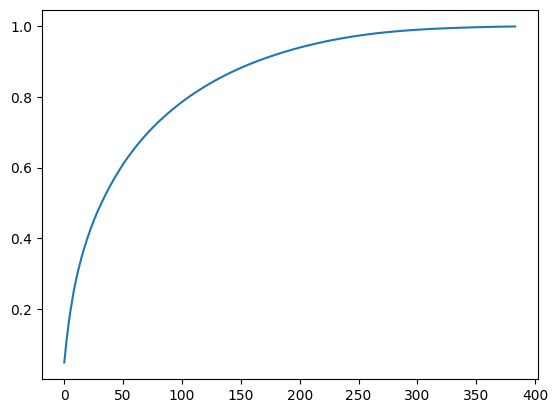

In [16]:
import matplotlib.pyplot as plt
pca = PCA(n_components=None)
check_suitable_n = pca.fit_transform(verse_embeddings_tensor_scaled)
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [17]:
pca = PCA(n_components=2)
verse_embeddings_tensor_scaled_pca = pca.fit_transform(verse_embeddings_tensor_scaled)

In [18]:
df_pca = pd.DataFrame(
    verse_embeddings_tensor_scaled_pca, 
    index=pd.DataFrame(verse_embeddings_tensor).index, 
    columns=["PC1", "PC2"]
)

In [19]:
import plotly.express as px

# Assuming df_pca is already defined and contains PC1, PC2 columns
# and that its index holds labels or identifiers for each point:
px.scatter(
    df_pca,
    x='PC1',
    y='PC2',
    hover_name=df_pca.index,
    title='PCA Projection of Embeddings',
    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'}
)



In [20]:
verse_embeddings_list = df_pca.values.tolist()
verse_embeddings_list

[[-3.2415359020233154, -2.311657428741455],
 [-4.6355791091918945, -7.072522163391113],
 [1.304123044013977, -8.200875282287598],
 [0.7420597672462463, -4.469945907592773],
 [-4.112975597381592, -1.8082019090652466],
 [-3.463578224182129, -2.160935878753662],
 [-3.9506752490997314, -0.8723040819168091],
 [-4.303136348724365, 2.7116122245788574],
 [3.7099523544311523, -3.21097993850708],
 [7.571324825286865, 1.373602271080017],
 [4.849785804748535, -3.491525411605835],
 [-4.360063552856445, -9.196484565734863],
 [-3.0859973430633545, -0.004925665911287069],
 [-1.5628440380096436, -0.7342328429222107],
 [-2.2238006591796875, -4.377109050750732],
 [2.3141229152679443, -5.268396377563477],
 [-3.0473053455352783, -0.6190374493598938],
 [-3.1377036571502686, 1.730860710144043],
 [-6.7196879386901855, 0.33900994062423706],
 [-5.67930269241333, 2.5145211219787598],
 [-4.940948963165283, 1.1750729084014893],
 [-3.771092176437378, 3.9345688819885254],
 [-8.904986381530762, 4.176037311553955],
 [

In [21]:
# Directly convert the underlying NumPy array to a FloatTensor
verse_embeddings_tensor = torch.tensor(df_pca.values, dtype=torch.float32)
verse_embeddings_tensor

tensor([[-3.2415, -2.3117],
        [-4.6356, -7.0725],
        [ 1.3041, -8.2009],
        ...,
        [-7.1105,  1.9439],
        [-3.7955, -6.5589],
        [-1.9198, -7.1598]])

In [22]:
# Determine device
device = 0 if torch.cuda.is_available() else -1
device_name = "GPU"
# if device == 0 else "CPU"
print(f"Attempting to load model on: {device_name}")

Attempting to load model on: GPU


In [23]:
verifier_model_name = "google/flan-t5-large" # Reverted to user's original model
print(f"Loading LLM for verification: {verifier_model_name}...")


Loading LLM for verification: google/flan-t5-large...


In [24]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(verifier_model_name, trust_remote_code=True)
# if tokenizer.pad_token is None:
#     tokenizer.pad_token = tokenizer.eos_token # Common practice for models without a pad token
#     print("Set tokenizer pad_token to eos_token.")


In [25]:
# Configure 4-bit quantization
# quantization_config = BitsAndBytesConfig(
#     load_in_4bit=True,                     # ← enable only 4-bit
#     bnb_4bit_quant_type="nf4",             # ← Normal Float 4 quantization
#     bnb_4bit_use_double_quant=True,        # ← nested quantization
#     bnb_4bit_compute_dtype=torch.bfloat16  # ← computation in bfloat16
# )



# Configure 8-bit quantization
quantization_config = BitsAndBytesConfig(
    load_in_8bit=True,                 # ← enable only 8-bit
    llm_int8_enable_fp32_cpu_offload=True # ← offload FP32 outliers to CPU
)


In [26]:


model_llm = AutoModelForSeq2SeqLM.from_pretrained(
        verifier_model_name,
        trust_remote_code=True,
        # quantization_config=quantization_config,
        device_map="auto",      # automatically shards layers onto GPU/CPU
        torch_dtype=torch.bfloat16
    )
print(f"LLM model_llm loaded. Initializing on device(s) via device_map.")


LLM model_llm loaded. Initializing on device(s) via device_map.


In [27]:
if hasattr(model_llm, 'hf_device_map'):
    print(f"LLM hf_device_map: {model_llm.hf_device_map}")

LLM hf_device_map: {'': 0}


In [28]:
if model_llm:
    print(f"Creating LLM pipeline...")
    pipe_llm = pipeline(
        task="text2text-generation",
        model=model_llm,
        tokenizer=tokenizer,
        
    )

verifier_pipeline = HuggingFacePipeline(pipeline=pipe_llm)
print(f"HuggingFace pipeline created. Effective pipeline device: {pipe_llm.device}")
if hasattr(verifier_pipeline, 'device'):
        print(f"Langchain verifier_pipeline reports device: {verifier_pipeline.device}")

Device set to use cuda:0


Creating LLM pipeline...
HuggingFace pipeline created. Effective pipeline device: cuda:0


# For the single statement

In [29]:
# This format is generally good for Phi instruction models.
# The prompt should end with <|assistant|> for the model to generate the response.
few_prompt_template = """
You are a helpful assistant. Based *only and directly* on the provided Ramayana Context, determine if the Statement is TRUE, FALSE, or NONE.
Output only the single word TRUE, FALSE, or NONE.

Definitions:
- TRUE — explicitly and unambiguously confirmed by the context.
- FALSE — explicitly contradicted or logically impossible based on the context.
- NONE — not covered, too vague, or unrelated to the Ramayana context provided.

Rules:
1. If a statement is *partially true* or contains errors based on the context, answer FALSE.
2. If the statement requires assumptions beyond the provided context or is subjective, answer NONE.
3. Use only literal matches from the context; do not infer.

Output exactly one uppercase word.

Examples:
Context: "Valmiki asked Narada, 'Who among sages is eloquent and eminent?'"
Statement: Valmiki initiated the conversation with Narada.
Answer: TRUE

Context: "King Dasharatha had three wives: Kausalya, Sumitra, and Kaikeyi."
Statement: Kaikeyi was not one of Dasharatha’s wives.
Answer: FALSE

Context: "Ravana had ten heads and twenty arms."
Statement: Ravana had only one head and two arms.
Answer: FALSE


Context: "Bharta was the brother of Rama from Ayodhya"
Statement: Bharata was originally from Lanka.
Answer: FALSE


Context: "The weather forecast predicted rain for the weekend."
Statement: It rained heavily all weekend.
Answer: NONE


---
Now, based on the following context and statement:
Context: "context"
Statement: {stmt}
Answer:<|end|>
<|assistant|>
"""

In [30]:
relevance_threshold_single = 0.30
top_n_context_single = 15
max_context_tokens_single = 1024

In [31]:
my_statement = "Bharata built a grand palace in Lanka following Rama’s victory over Ravana."
print(f"Checking the statement: '{my_statement}'")

Checking the statement: 'Bharata built a grand palace in Lanka following Rama’s victory over Ravana.'


In [32]:
pipeline_ready = (
    original_verses_cleaned and
    embedding_model_st is not None and
    verifier_pipeline is not None and
    verse_embeddings_tensor is not None and verse_embeddings_tensor.numel() > 0 and
    few_prompt_template and # Use the generic few_prompt_template
    my_statement
)

In [33]:
pipeline_ready

'Bharata built a grand palace in Lanka following Rama’s victory over Ravana.'

In [34]:
# The pipeline is ready so....................

In [35]:
stmt_emb_np_raw = embedding_model_st.encode(my_statement)
stmt_emb_raw = torch.tensor(stmt_emb_np_raw, device=embedding_device) # Ensure it's on CPU
# stmt_emb_raw

In [36]:
if stmt_emb_raw.ndim == 1:
    stmt_emb_raw = stmt_emb_raw.unsqueeze(0)
print(f"Statement embedding created on device: {stmt_emb_raw.device}, Shape: {stmt_emb_raw.shape}")

Statement embedding created on device: cpu, Shape: torch.Size([1, 384])


In [37]:
# stmt_emb_raw.numpy().reshape(1, -1)

In [38]:
#  1. Transform your 384-d statement embedding into 2D:
stmt_pca = pca.transform(stmt_emb_raw.numpy().reshape(1, -1))  # shape (1,2)
stmt_pca

array([[-0.2886007 ,  0.43809396]], dtype=float32)

In [39]:
# 2. Convert to tensor:
stmt_pca_tensor = torch.tensor(stmt_pca, dtype=torch.float32)  # (1,2)
stmt_pca_tensor

tensor([[-0.2886,  0.4381]])

In [40]:

# 3. Now compute cosine‐similarity against your df_pca tensor:
cos_scores_raw = util.cos_sim(stmt_pca_tensor, torch.tensor(df_pca.values, dtype=torch.float32))[0]
cos_scores_raw

tensor([-0.0370, -0.3969, -0.9111,  ...,  0.7509, -0.4473, -0.6641])

In [41]:
# 2. Calculate cosine similarity (both tensors on CPU)
# cos_scores_raw = util.cos_sim(stmt_emb_raw, verse_embeddings_tensor)[0] # Result will be on CPU
# print(f"Cosine similarity scores calculated. Shape: {cos_scores_raw.shape}, Device: {cos_scores_raw.device} is {cos_scores_raw}")

In [42]:
# 3. Retrieve and filter context
max_score_raw = torch.max(cos_scores_raw).item()
# print(f"Max similarity score = {max_score_raw:.4f}")
max_score_raw

1.0

In [43]:
is_relevant_raw = max_score_raw >= relevance_threshold_single
# print(f"Is statement potentially relevant based on threshold? {is_relevant_raw}")
is_relevant_raw


True

In [44]:
actual_top_n_raw = min(top_n_context_single, len(original_verses_cleaned))
actual_top_n_raw

15

In [45]:
retrieved_verses_final_for_context = []
if actual_top_n_raw > 0 and cos_scores_raw.numel() > 0:
    k_for_topk = min(actual_top_n_raw, cos_scores_raw.shape[0])
    if k_for_topk > 0:
        top_results_raw = torch.topk(cos_scores_raw, k=k_for_topk)
        top_indices_raw = top_results_raw.indices.tolist()
        top_scores_raw = top_results_raw.values.tolist()

        for i, score in zip(top_indices_raw, top_scores_raw):
            if score >= relevance_threshold_single:
                retrieved_verses_final_for_context.append(original_verses_cleaned[i])

        print(f"Retrieved {len(top_indices_raw)} verses initially. After filtering by threshold {relevance_threshold_single:.2f}, {len(retrieved_verses_final_for_context)} verses remain for context.")
    else:
        print("Warning: k for topk is 0. No context retrieved.")
else:
    print("Warning: Not enough data to retrieve context or actual_top_n_raw is 0.")


Retrieved 15 verses initially. After filtering by threshold 0.30, 15 verses remain for context.


In [46]:
top_results_raw

torch.return_types.topk(
values=tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]),
indices=tensor([ 7170,  1394,  4116, 14623, 15244,  7903, 13999,  3271,  7407, 12046,
         6042, 10552, 11584,  2830,  5167]))

In [47]:
top_indices_raw

[7170,
 1394,
 4116,
 14623,
 15244,
 7903,
 13999,
 3271,
 7407,
 12046,
 6042,
 10552,
 11584,
 2830,
 5167]

In [48]:
top_scores_raw

[1.0,
 0.9999999403953552,
 0.9999999403953552,
 0.9999999403953552,
 0.9999999403953552,
 0.9999998211860657,
 0.9999997019767761,
 0.9999994039535522,
 0.9999993443489075,
 0.9999992847442627,
 0.9999989867210388,
 0.9999987483024597,
 0.9999980926513672,
 0.9999979138374329,
 0.9999977946281433]

In [49]:
if not retrieved_verses_final_for_context:
    print("No relevant verses found after filtering. Using empty context for LLM.")
    context_str_truncated_raw = ""
else:
    context_str_raw = "\n\n".join(retrieved_verses_final_for_context)
    context_tokens_raw = tokenizer.encode(context_str_raw, max_length=max_context_tokens_single, truncation=True, add_special_tokens=False)
    context_str_truncated_raw = tokenizer.decode(context_tokens_raw, skip_special_tokens=True)
    print(f"Truncated context length (chars): {len(context_str_truncated_raw)}")


Truncated context length (chars): 1763


In [50]:
# context_str_raw,context_tokens_raw,context_str_truncated_raw

In [51]:
prompt_raw = few_prompt_template.format(stmt=my_statement, context=context_str_truncated_raw)
prompt_raw

'\nYou are a helpful assistant. Based *only and directly* on the provided Ramayana Context, determine if the Statement is TRUE, FALSE, or NONE.\nOutput only the single word TRUE, FALSE, or NONE.\n\nDefinitions:\n- TRUE — explicitly and unambiguously confirmed by the context.\n- FALSE — explicitly contradicted or logically impossible based on the context.\n- NONE — not covered, too vague, or unrelated to the Ramayana context provided.\n\nRules:\n1. If a statement is *partially true* or contains errors based on the context, answer FALSE.\n2. If the statement requires assumptions beyond the provided context or is subjective, answer NONE.\n3. Use only literal matches from the context; do not infer.\n\nOutput exactly one uppercase word.\n\nExamples:\nContext: "Valmiki asked Narada, \'Who among sages is eloquent and eminent?\'"\nStatement: Valmiki initiated the conversation with Narada.\nAnswer: TRUE\n\nContext: "King Dasharatha had three wives: Kausalya, Sumitra, and Kaikeyi."\nStatement: K

In [52]:
result_text = verifier_pipeline(prompt_raw, temperature=0.0)

In [53]:
result_text

'TRUE'

In [54]:
# Process LLM output to get a clean TRUE/FALSE/NONE

valid_answers = {"TRUE", "FALSE", "NONE"}
parts = result_text.split()
result_text_raw = "NONE"  # Default if parsing fails or output is unexpected
if parts:
    first_word = parts[0]
    if first_word in valid_answers:
        result_text_raw = first_word
    # else: you could add a print(f"Warning: Unexpected LLM output start: {first_word}")

print(result_text_raw) # Display the cleaned result

TRUE


In [55]:
# Robust checking
if result_text.startswith("TRUE"):
    print(True)
elif result_text.startswith("FALSE"):
    print(False)
elif result_text.startswith("NONE"):
    print(None)
else:
    # Fallback check if startswith fails
    if "TRUE" in result_text:
        print(True)
    if "FALSE" in result_text:
        print(False)
    if "NONE" in result_text:
        print(None)

    print(f"Warning: Model output '{result_text}' not clearly TRUE, FALSE, or UNKNOWN.")
    print(None) # Cannot determine

True


In [56]:
import pandas as pd
df_initial = pd.read_csv('initial.csv')
df_initial.head()


,ID,Statement,Truth,Reference
0,1,Rama is the eldest son of King Dasharatha.,True,"Bala Kanda, Sarga 18, Shloka 24"
1,2,Sita was discovered by King Janaka in a furrow...,True,"Bala Kanda, Sarga 66, Shloka 14"
2,3,"Lakshmana, Rama’s devoted younger brother, acc...",True,"Ayodhya Kanda, Sarga 31, Shloka 30"
3,4,"Bharata, another brother of Rama, revered him ...",True,"Ayodhya Kanda, Sarga 115, Shloka 22"
4,5,Hanuman was the best minister of Sugreeva.,True,"Kishkindha Kanda, Sarga 6, Shloka 2"


In [59]:
from sklearn.decomposition import PCA # Import PCA
# Lists to store results
predicted_truths = []
actual_truths = []
statements_list = []
retrieved_contexts_list = [] # To store retrieved contexts for the DataFrame

# --- PCA Setup ---
# Ensure verse_embeddings_np is available from a previous cell (e.g., id="2896e941")
# and embedding_device is defined (e.g., as torch.device("cpu"))
n_pca_components = 290 

if verse_embeddings_np.shape[1] < n_pca_components: # Check against number of features
    print(f"Warning: Number of features in original embeddings ({verse_embeddings_np.shape[1]}) is less than n_pca_components ({n_pca_components}). Adjusting n_pca_components.")
    n_pca_components = verse_embeddings_np.shape[1]

pca = PCA(n_components=n_pca_components)

print(f"Original verse embedding shape: {verse_embeddings_np.shape}")
# Fit PCA on the verse embeddings and transform them
if verse_embeddings_np.shape[0] < n_pca_components:
    print(f"Warning: Number of samples ({verse_embeddings_np.shape[0]}) is less than n_components ({n_pca_components}). Adjusting n_components for PCA fit.")
    # This case might indicate very few verses, PCA might not be very effective or could error.
    # Consider skipping PCA or using a different n_components strategy if this is common.
    # For now, we'll adjust n_pca_components to the number of samples if it's smaller.
    pca_fit_components = min(n_pca_components, verse_embeddings_np.shape[0])
    pca = PCA(n_components=pca_fit_components)
    print(f"PCA n_components adjusted to {pca_fit_components} for fitting.")


verse_embeddings_pca_np = pca.fit_transform(verse_embeddings_np)
print(f"PCA-transformed verse embedding shape: {verse_embeddings_pca_np.shape}")
# Ensure embedding_device is defined, typically torch.device("cpu") for embeddings
verse_embeddings_pca_tensor = torch.tensor(verse_embeddings_pca_np, device=embedding_device) # Should be on CPU

print("Starting verification process for each statement in df_initial...")

# Iterate through the DataFrame rows
for index, row in df_initial.iterrows():
    statement = row['Statement']
    actual_truth = str(row['Truth']).upper()
    context_str_truncated_for_output = "No relevant context found." # Default message for context

    print(f"\nProcessing statement {index + 1}/{len(df_initial)}: '{statement}'")

    # --- RAG Verification Logic for a Single Statement ---
    predicted_truth = "ERROR" # Default to ERROR in case of exceptions

    try:
        # 1. Create embedding for the statement (ensure on embedding_device - CPU)
        stmt_emb_np = embedding_model_st.encode(statement) # This is (original_dim,)
        
        # Transform statement embedding using the fitted PCA model
        stmt_emb_2d_np = stmt_emb_np.reshape(1, -1) # PCA transform expects 2D array (1, original_dim)
        stmt_emb_pca_np = pca.transform(stmt_emb_2d_np) # Output is (1, n_pca_components)
        
        # embedding_model_st.device should be CPU
        stmt_emb_pca_tensor = torch.tensor(stmt_emb_pca_np, device=embedding_model_st.device) 
        # stmt_emb_pca_tensor will be shape (1, n_pca_components)

        # 2. Calculate cosine similarity (both tensors on CPU)
        # Use PCA-transformed embeddings
        cos_scores = util.cos_sim(stmt_emb_pca_tensor, verse_embeddings_pca_tensor)[0]

        # 3. Retrieve and filter context
        retrieved_verses_for_context = []
        actual_top_n = min(top_n_context_single, len(original_verses_cleaned))

        if actual_top_n > 0 and cos_scores.numel() > 0:
             k_for_topk = min(actual_top_n, cos_scores.shape[0])
             if k_for_topk > 0:
                top_results = torch.topk(cos_scores, k=k_for_topk)
                top_indices = top_results.indices.tolist()
                top_scores = top_results.values.tolist()

                for i, score_val in zip(top_indices, top_scores): # Renamed score to score_val
                    if score_val >= relevance_threshold_single:
                        retrieved_verses_for_context.append(original_verses_cleaned[i])

        # 4. Join context and truncate
        if not retrieved_verses_for_context:
             context_str_truncated = ""
             # context_str_truncated_for_output remains "No relevant context found."
        else:
            context_str = "\\n\\n".join(retrieved_verses_for_context)
            # Tokenize context and truncate to max_context_tokens
            context_tokens = tokenizer.encode(context_str, max_length=max_context_tokens_single, truncation=True, add_special_tokens=False)
            context_str_truncated = tokenizer.decode(context_tokens, skip_special_tokens=True)
            context_str_truncated_for_output = context_str_truncated # Update with actual retrieved context


        # 5. Prepare prompt for LLM
        formatted_prompt = few_prompt_template.replace("Context: \"context\"", f"Context: \"{context_str_truncated}\"")
        final_prompt = formatted_prompt.format(stmt=statement)

        # 6. Get response from LLM
        raw_llm_output = str(verifier_pipeline(final_prompt, temperature=0.0))

        # 7. Parse the LLM output
        valid_answers = {"TRUE", "FALSE", "NONE"}
        parsed_answer = "NONE" 

        cleaned_output = raw_llm_output.strip().upper()
        parts = cleaned_output.split()

        if parts:
            first_word = parts[0]
            if first_word in valid_answers:
                parsed_answer = first_word
            else:
                for ans in valid_answers:
                    if ans in cleaned_output:
                         parsed_answer = ans 
                         break 

        predicted_truth = parsed_answer

    except Exception as e:
        print(f"An error occurred processing statement '{statement}': {e}")
        predicted_truth = "ERROR" 
    # --- End of  Verification Logic ---

    print(f"Retrieved Context: {context_str_truncated_for_output}") 
    print(f"Actual: {actual_truth}, Predicted: {predicted_truth}")

    predicted_truths.append(predicted_truth)
    actual_truths.append(actual_truth)
    statements_list.append(statement)
    retrieved_contexts_list.append(context_str_truncated_for_output) 

print("\nVerification process complete.")

results_df = pd.DataFrame({
    'Original_Statement': statements_list,
    'Actual_Truth': actual_truths,
    'Predicted_Truth': predicted_truths,
    'Retrieved_Context': retrieved_contexts_list 
})

results_df['Match'] = results_df.apply(
    lambda row: row['Actual_Truth'] == row['Predicted_Truth'] if row['Predicted_Truth'] != 'ERROR' else False,
    axis=1
)

print("\nVerification Results:")
display(results_df)

comparable_results = results_df[results_df['Predicted_Truth'] != 'ERROR']
if not comparable_results.empty:
    accuracy = comparable_results['Match'].mean() * 100
    print(f"\nAccuracy (excluding errors): {accuracy:.2f}%")
else:
    print("\nNo comparable results to calculate accuracy.")



Original verse embedding shape: (18274, 384)
PCA-transformed verse embedding shape: (18274, 290)
Starting verification process for each statement in df_initial...

Processing statement 1/20: 'Rama is the eldest son of King Dasharatha.'
Retrieved Context: king named Dasharatha godlike valour eldest son people hear Ramann Rama son king Dasharatha born Ikshvaku dynasty adept virtue adherent father ordersnn king named Dasharatha eldest son dynamic Rama arrived wife Seetha sagenn Rama eldest son king Dasharatha established dear son Bharata king Rama spineless flight forests matter sovereigntynn king known Dasharatha enhancer Ikshvaku dynasty great resplendent son known Ramann Dasharatha son virtue souled highly renowned worlds ambidexterity perspicacity known Rama husband godnn Rama king shall happy father ruled grandfathers rulednn Sons King Dasharatha Rama Lakshmana entered threshold hermitage wife Rama Seethann Rama eldest son excellent man pious souled compared Dilipa Nahusha eligible k

,Original_Statement,Actual_Truth,Predicted_Truth,Retrieved_Context,Match
0,Rama is the eldest son of King Dasharatha.,TRUE,TRUE,king named Dasharatha godlike valour eldest so...,True
1,Sita was discovered by King Janaka in a furrow...,TRUE,TRUE,finding Sita Raghu dynasty valiant Lakshmana r...,True
2,"Lakshmana, Rama’s devoted younger brother, acc...",TRUE,TRUE,Rama elder brother Lakshmana introduced sage f...,True
3,"Bharata, another brother of Rama, revered him ...",TRUE,TRUE,Rama kingdom Bharata Rama esteems brothers sel...,True
4,Hanuman was the best minister of Sugreeva.,TRUE,TRUE,Hanuman speaking melodious words politeness sa...,True
5,"Ravana, the demon king of Lanka, abducted Sita...",TRUE,TRUE,Entering Lanka filled demons night saw Ravana ...,True
6,"On seeing Hanuman, Sita lost her consciousness...",TRUE,TRUE,soon seeing Hanuma Seetha lost consciousness s...,True
7,"Nila, a general of the monkey army, was render...",TRUE,TRUE,Nila Army General Monkeys tormented hail arrow...,True
8,Nala constructed a bridge for Rama to cross ov...,TRUE,TRUE,Crossing ocean boulder bridge built Nala seizu...,True
9,The sage Vishwamitra mentored Rama during his ...,TRUE,TRUE,highly resplendent Rama revered sage Vishvamit...,True



Accuracy (excluding errors): 85.00%


In [60]:
results_df.to_csv("Statements_predictions.csv",index=False)